In [ ]:
import omicverse as ov
import scanpy as sc
import scvi
import numpy as np
import matplotlib.pyplot as plt 
import scvelo as scv
import torch
import anndata as ad
import pooch
from matplotlib.colors import LinearSegmentedColormap

# Define a custom colormap
custom_cmap = LinearSegmentedColormap.from_list(
    'custom_blue_green', ['cyan', 'red'], N=256
)

# 全局设置 Matplotlib 的字体和字号
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

sc.settings.set_figure_params(dpi=300, facecolor="white")
sc.set_figure_params(figsize=(6, 6), frameon=False)
torch.set_float32_matmul_precision("middle")
%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

In [2]:
adata = sc.read_h5ad('D:/AI work/scRNA_ad/adata_mic_20250514.h5ad')

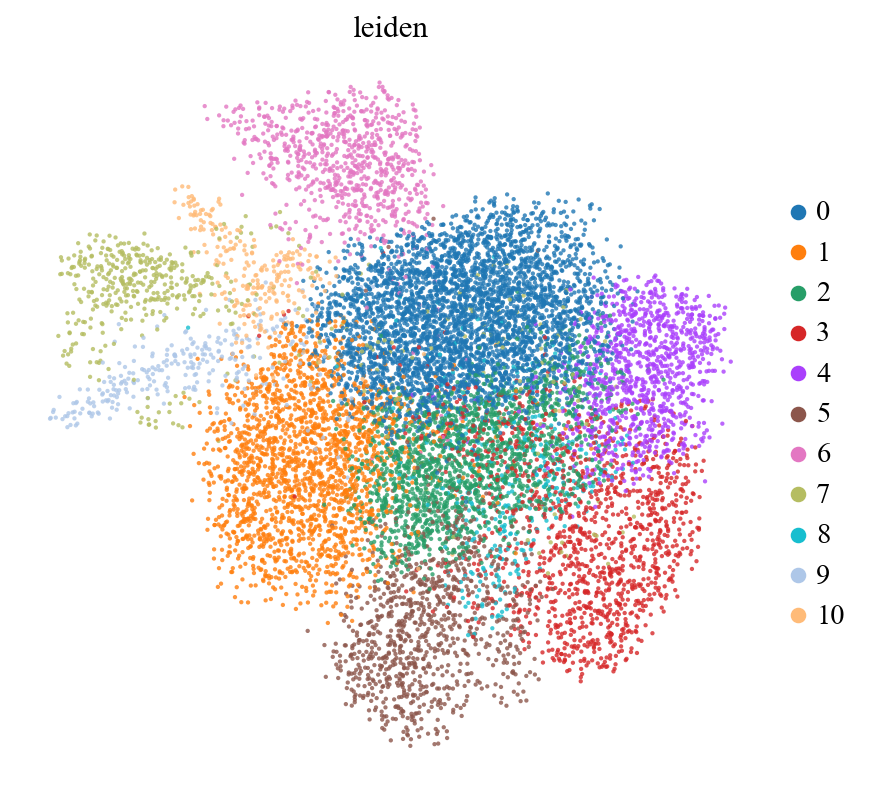

In [37]:
sc.pl.umap(
    adata,
    color=['leiden'],
    cmap=custom_cmap,
    size=15,
    alpha=0.8,
    frameon=False,
    #legend_loc = 'on data',
    show=False
)
# 保存当前图形为 TIFF 格式，dpi 和 bbox_inches 可根据需要调整
plt.savefig("D:/AI work/scRNA_AD/output/mic_group_new_umap_plot_legend_ondata.tif", format="tif", dpi=300, bbox_inches="tight")

# 如果需要，还可以显示图形
plt.show()

In [3]:
group_map = {
    'Low_3_2':  'AD',      # Previously Low_Tau
    'Low_2_2':  'Non_AD',
    'Low_5_2':  'AD',      # Previously Low_Tau
    'Low_4_2':  'AD',      # Previously Low_Tau
    'Low_12_2': 'AD',      # Previously Low_Tau
    'Low_13_2': 'Non_AD',
    'Low_11_2': 'AD',      # Previously Low_Tau
    'Low_10_2': 'AD',      # Previously Low_Tau
    'Low_16_2': 'AD',      # Previously Low_Tau
    'Low_31':   'AD',      # Previously Low_Tau
    'High_7_2':  'AD',     # Previously High_Tau
    'High_1_2':  'AD',     # Previously High_Tau
    'High_9_2':  'AD',     # Previously High_Tau
    'High_19_2': 'AD',     # Previously High_Tau
    'High_33':   'AD',     # Previously High_Tau
    'High_34':   'AD',     # Previously High_Tau
    'Non_1':    'Non_AD',
    'Non_28':   'AD',      # Previously High_Tau
    'Non_2':    'Non_AD',
    'Non_35':   'Non_AD',
    'Non_8_2':  'Non_AD',
    'Non_14_2': 'Non_AD'
}
adata.obs['AD'] = adata.obs['sample'].map(group_map).astype('category')

NameError: name 'adata' is not defined

In [25]:
sc.settings.figdir = "D:/AI work/scRNA_AD/output"
sc.settings.file_format_figs = "tif"  # 将默认输出格式由 pdf 改为 tif

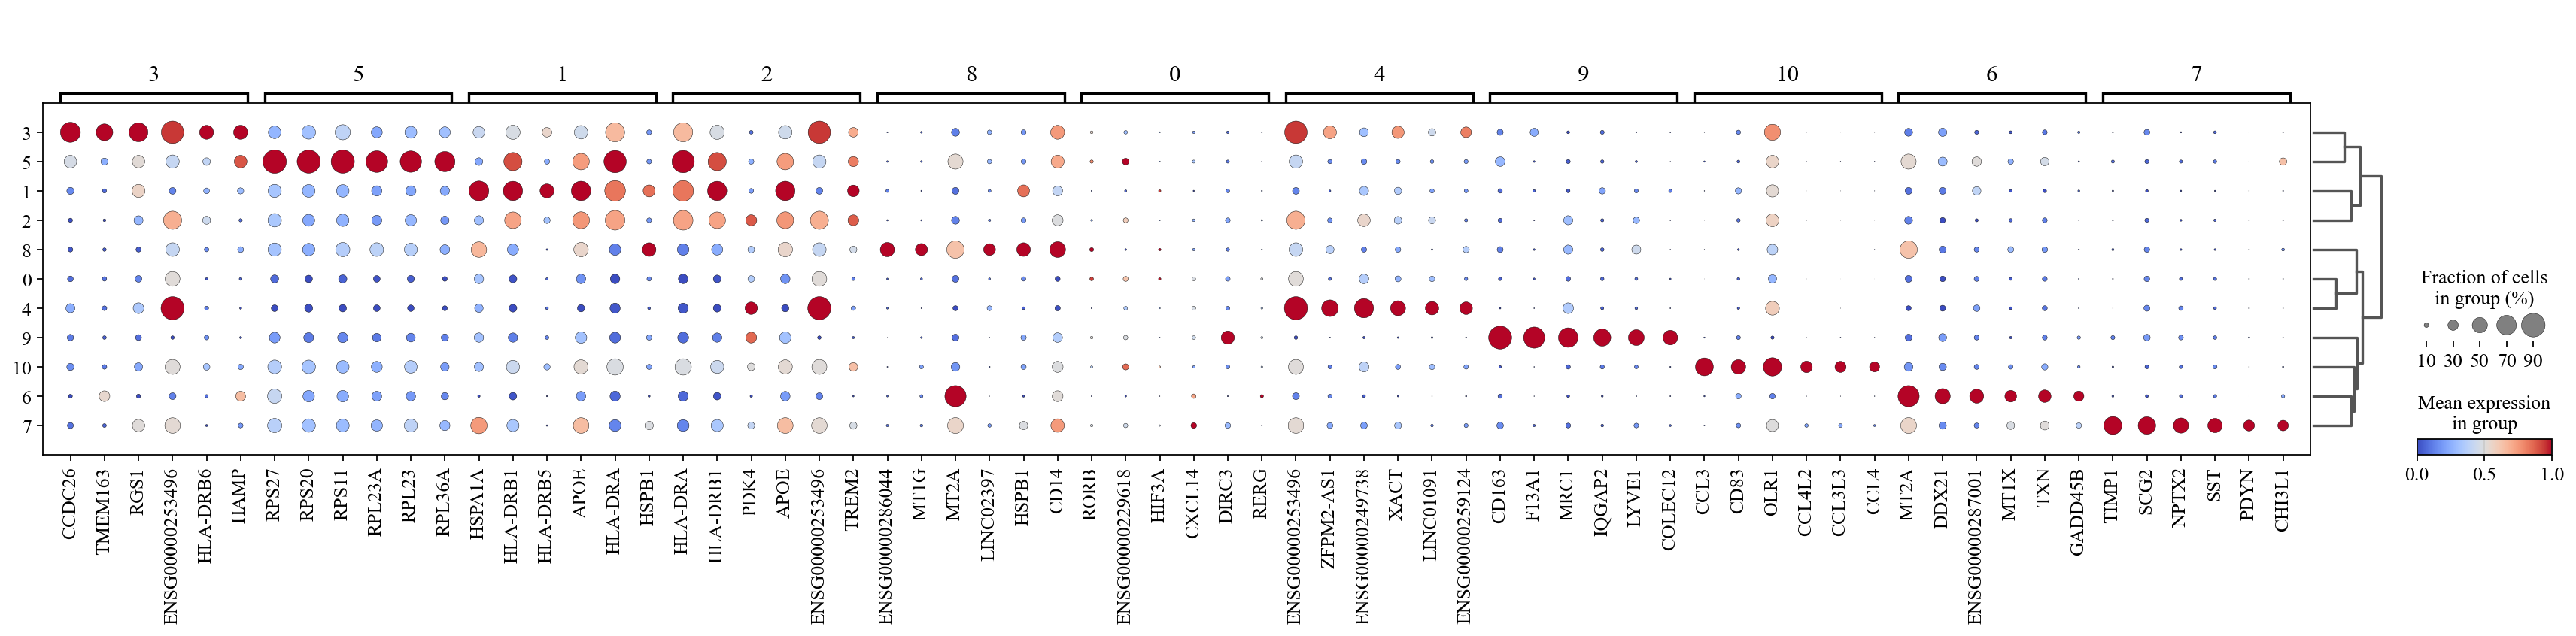

In [30]:
sc.pl.rank_genes_groups_dotplot(
    adata,
    groupby='leiden',
    key='leiden_ttest',
    cmap='coolwarm',  # 替换为 'plasma'、'magma'、'cividis'、'RdBu_r' 或 'coolwarm'
    standard_scale='var',
    n_genes=6,
    save='leiden_dotplot_inferno'  # 注意不要加扩展名，由Scanpy自动处理
)

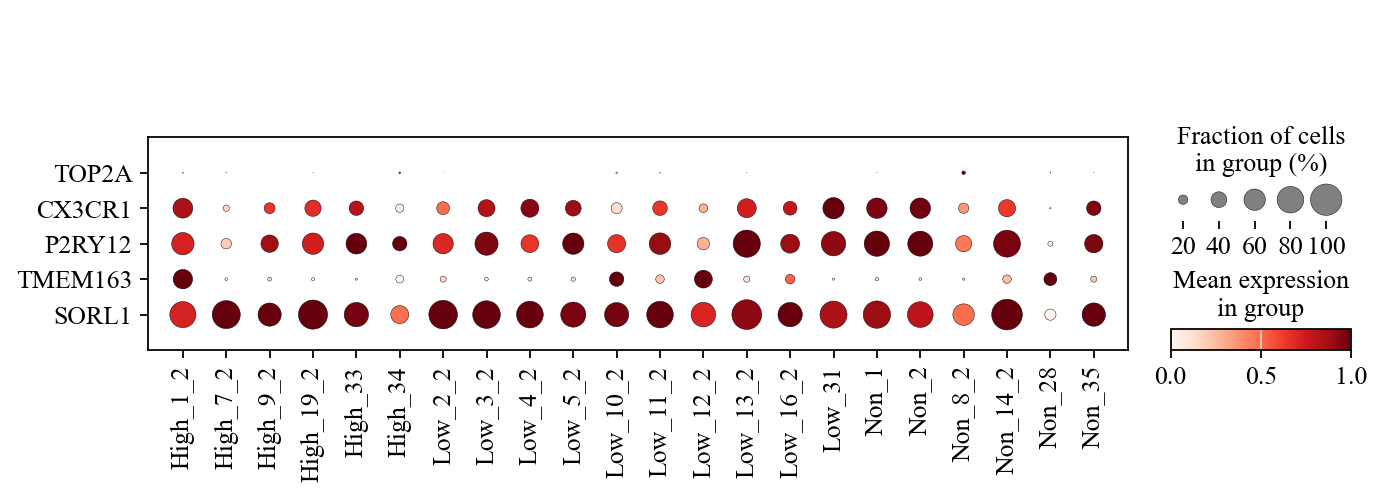

In [46]:
marker_genes = ['TOP2A','CX3CR1','P2RY12','TMEM163','SORL1']
sc.pl.dotplot(adata, marker_genes, groupby='sample',
             standard_scale='var',swap_axes=True);

In [40]:
adata_ac = sc.read_h5ad('D:/AI work/scRNA_ad/ac_subset.h5ad')

In [41]:
adata_ac

AnnData object with n_obs × n_vars = 19796 × 32176
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'sample', 'leiden', 'group', 'cell_label', 'leiden_group', 'group_new'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'cell_label_colors', 'group_colors', 'group_new_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_harmony', 'X_mde_harmony', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [ ]:
sc.pl.umap(
    adata_ac,
    color=['leiden'],
    cmap=custom_cmap,
    size=15,
    alpha=0.8,
    frameon=False,
    #legend_loc = 'on data',
    show=False
)

In [43]:
%%time
adata_ac=ov.pp.preprocess(adata_ac,mode='shiftlog|pearson',n_HVGs=2000,
                       target_sum=50*1e4)
adata_ac

Begin robust gene identification
After filtration, 29936/32176 genes are kept.     Among 29936 genes, 24746 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
Time to analyze data in cpu: 5.3105504512786865 seconds.
End of size normalization: shiftlog and HVGs selection pearson
CPU times: total: 13.7 s
Wall time: 6.58 s


AnnData object with n_obs × n_vars = 19796 × 24746
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'sample', 'leiden', 'group', 'cell_label', 'leiden_group', 'group_new'
    var: 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'n_cells', 'percent_cells', 'robust', 'residual_variances', 'highly_variable_features'
    uns: 'cell_label_colors', 'group_colors', 'group_new_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_harmony', 'X_mde_harmony', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [45]:
%%time
adata_ac.raw = adata
adata_ac = adata_ac[:, adata_ac.var.highly_variable_features]
adata_ac

CPU times: total: 31.2 ms
Wall time: 33.5 ms


View of AnnData object with n_obs × n_vars = 19796 × 2000
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'sample', 'leiden', 'group', 'cell_label', 'leiden_group', 'group_new'
    var: 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'n_cells', 'percent_cells', 'robust', 'residual_variances', 'highly_variable_features'
    uns: 'cell_label_colors', 'group_colors', 'group_new_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_harmony', 'X_mde_harmony', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [49]:
%%time
ov.pp.scale(adata_ac)
adata_ac

CPU times: total: 906 ms
Wall time: 759 ms


AnnData object with n_obs × n_vars = 19796 × 2000
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'sample', 'leiden', 'group', 'cell_label', 'leiden_group', 'group_new'
    var: 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'n_cells', 'percent_cells', 'robust', 'residual_variances', 'highly_variable_features'
    uns: 'cell_label_colors', 'group_colors', 'group_new_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_harmony', 'X_mde_harmony', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'scaled'
    obsp: 'connectivities', 'distances'

In [50]:
%%time
ov.pp.pca(adata_ac,layer='scaled',n_pcs=50)
adata_ac

CPU times: total: 43 s
Wall time: 3.92 s


AnnData object with n_obs × n_vars = 19796 × 2000
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'sample', 'leiden', 'group', 'cell_label', 'leiden_group', 'group_new'
    var: 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'n_cells', 'percent_cells', 'robust', 'residual_variances', 'highly_variable_features'
    uns: 'cell_label_colors', 'group_colors', 'group_new_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues'
    obsm: 'X_harmony', 'X_mde_harmony', 'X_pca', 'X_umap', 'scaled|original|X_pca'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'counts', 'scaled'
    obsp: 'connectivities', 'distances'

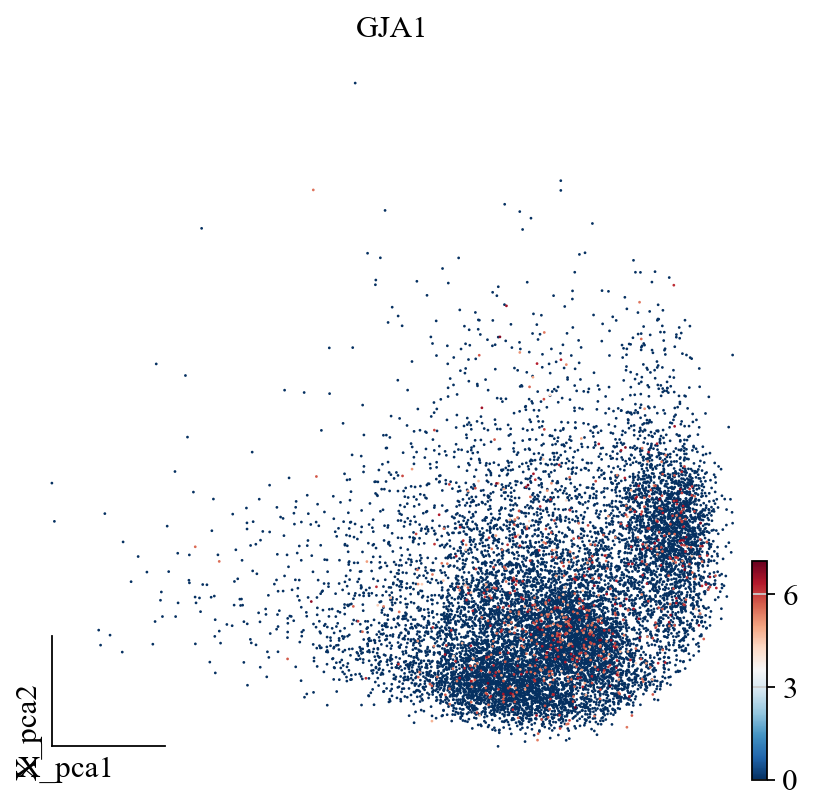

In [52]:
adata_ac.obsm['X_pca']=adata_ac.obsm['scaled|original|X_pca']
ov.pl.embedding(adata_ac,
                  basis='X_pca',
                  color='GJA1',
                  frameon='small')

In [53]:
%%time
ov.pp.neighbors(adata_ac, n_neighbors=15, n_pcs=50,
               use_rep='scaled|original|X_pca')

CPU times: total: 29.7 s
Wall time: 31.8 s


In [54]:
%%time
ov.pp.umap(adata_ac,n_components=50,min_dist=0.5)

CPU times: total: 20.7 s
Wall time: 20.9 s


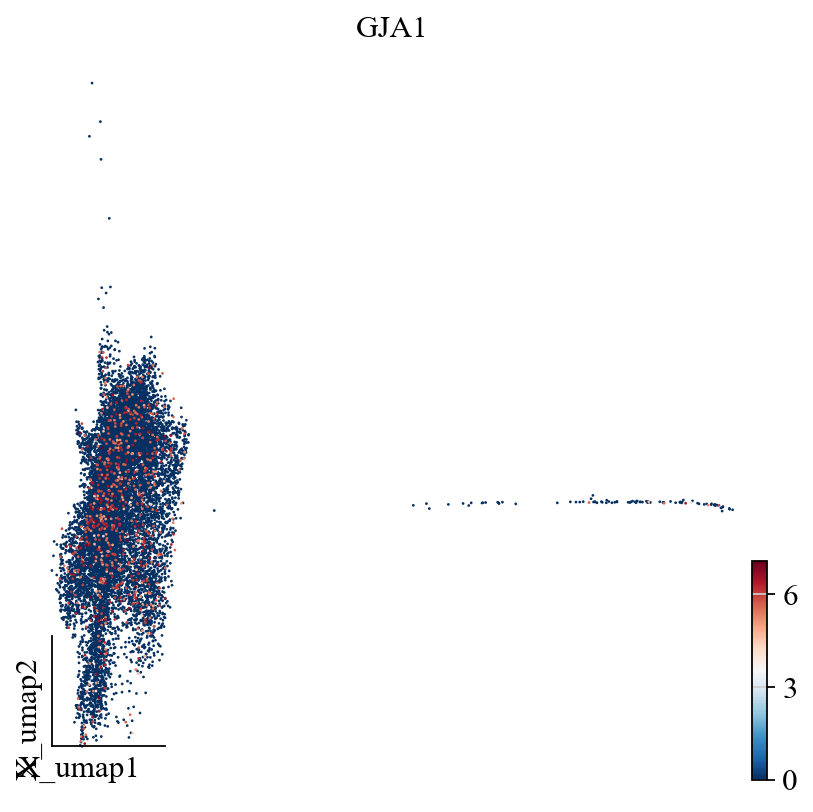

In [60]:
ov.pl.embedding(adata_ac,
                basis='X_umap',
                color='GJA1',
                frameon='small')

In [71]:
ov.pp.leiden(adata_ac,resolution=0.4)

In [69]:
# 删除 raw，避免对 raw 进行切片
adata_ac.raw = None  

# 构造掩码并子集化
mask = adata_ac.obs['leiden'] != '11'
adata_ac = adata_ac[mask, :].copy()

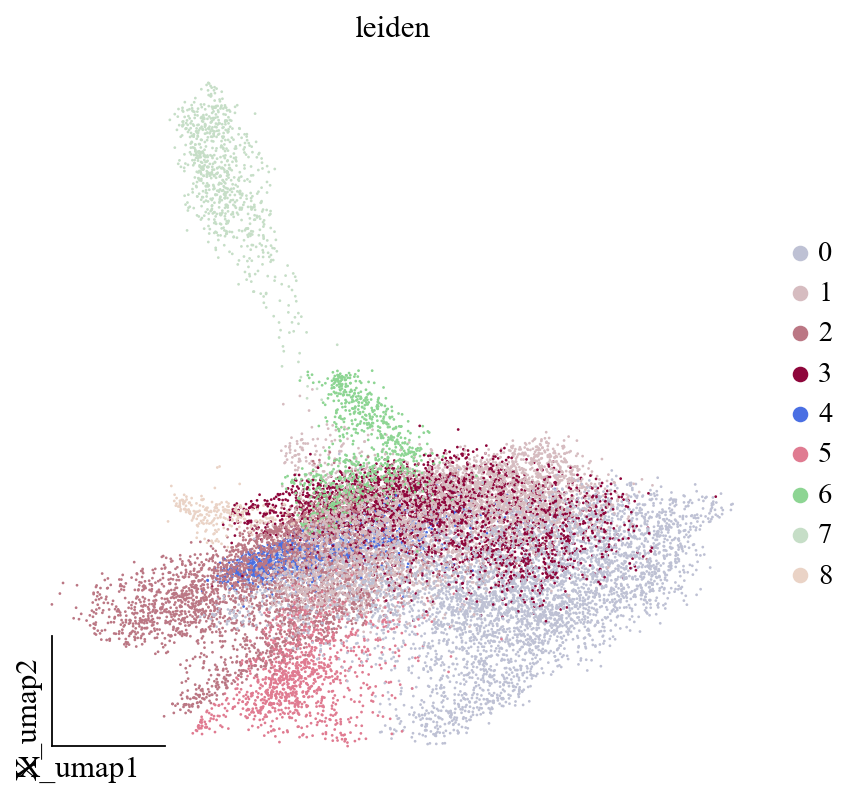

In [74]:
ov.pl.embedding(adata_ac,
                basis='X_umap',
                color='leiden',
                frameon='small')#,
                #legend_loc='on data')

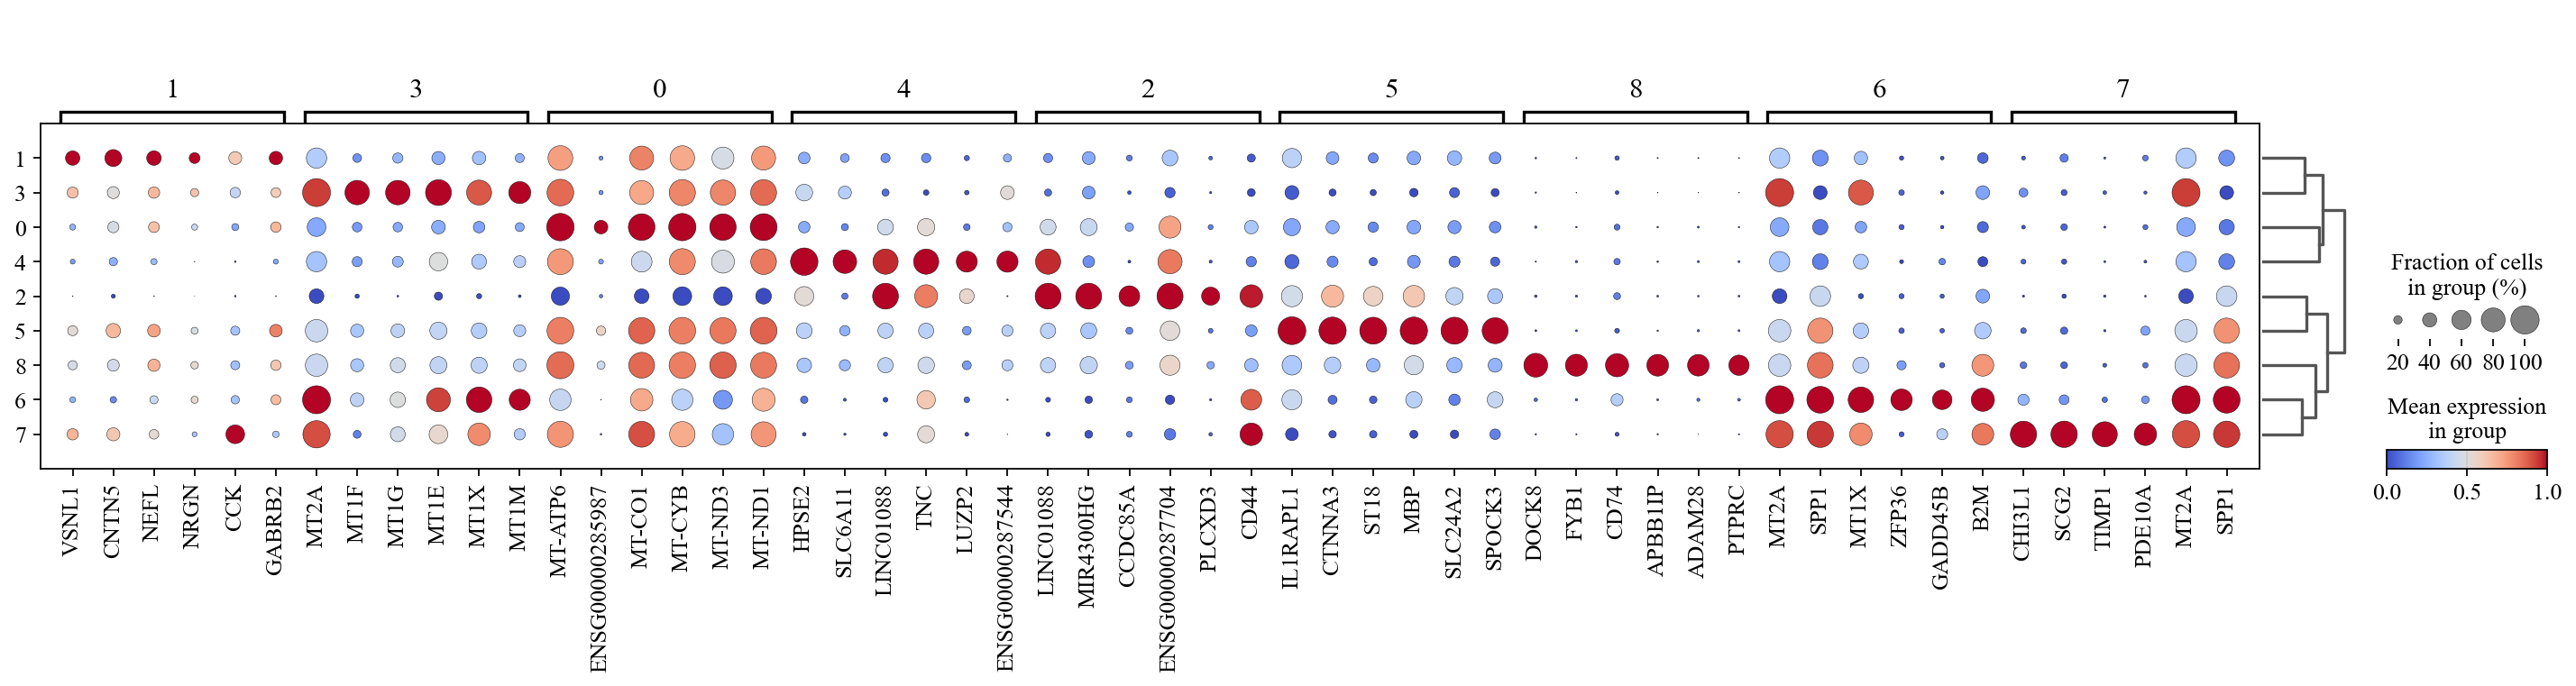

In [76]:
sc.tl.dendrogram(adata_ac,'leiden',use_rep='scaled|original|X_pca')
sc.tl.rank_genes_groups(adata_ac, 'leiden', use_rep='scaled|original|X_pca',
                        method='t-test',use_raw=False,key_added='leiden_ttest')
sc.pl.rank_genes_groups_dotplot(adata_ac,groupby='leiden',
                                cmap='coolwarm',key='leiden_ttest',
                                standard_scale='var',n_genes=6)

In [5]:
adata_ac

NameError: name 'adata_ac' is not defined